# AutoEncoder Experiment

### Notebook Structure
1. Motivation
2. Dataset Loading
3. Feature Preparation
4. AutoEncoder Architecture
5. Training Loop
6. Reconstruction Error Analysis
7. Isolation Forest Comparison
8. Latency Benchmark
9. MLflow Logging
10. Final Production Decision

# 1. AutoEncoder vs Isolation Forest

This experiment evaluates whether a lightweight PyTorch AutoEncoder
provides meaningful operational advantages over Isolation Forest for
streaming fraud anomaly detection.

The comparison focuses not only on anomaly sensitivity, but also on:
- inference latency
- operational complexity
- retraining simplicity
- deployment suitability
- streaming compatibility

The goal is to validate whether Isolation Forest remains the better
production choice for the RealSignal architecture.

In [ ]:
""" 
2. Dataset Loading
"""
import pandas as pd

FEATURE_COLUMNS = [
    "amount",
    "velocity_1m",
    "avg_amount_1m",
    "merchant_diversity_1m",
]

df = pd.read_csv(
    "../dataset/processed/transactions_dataset.csv"
)

X = df[FEATURE_COLUMNS]

print(X.head())

print(X.shape)

     amount  velocity_1m  avg_amount_1m  merchant_diversity_1m
0   2157.21            1        2157.21                      1
1    151.72            1         151.72                      1
2  82199.23            2       42178.22                      2
3    774.12            1         774.12                      1
4    190.38            2         171.05                      2
(5000, 4)


In [ ]:
"""
3. Feature Preparation
"""

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
import torch 

X_tensor = torch.tensor(X_scaled, dtype = torch.float32)

In [4]:
""" 
4. AutoEncoder Architecture
"""
import torch.nn as nn 

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(4, 8), nn.ReLU(),

            nn.Linear(8, 2), nn.ReLU() 
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),

            nn.Linear(8, 4)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)  

        return decoded 

In [5]:
"""
5. Training Setup
"""

model = AutoEncoder()
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [6]:
EPOCHS = 15

for epoch in range(EPOCHS):
    optimizer.zero_grad()

    reconstructed = model(X_tensor)
    
    loss = criterion(reconstructed, X_tensor)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

Epoch 1, Loss: 1.083139
Epoch 2, Loss: 1.080894
Epoch 3, Loss: 1.078675
Epoch 4, Loss: 1.076490
Epoch 5, Loss: 1.074335
Epoch 6, Loss: 1.072210
Epoch 7, Loss: 1.070123
Epoch 8, Loss: 1.068057
Epoch 9, Loss: 1.066012
Epoch 10, Loss: 1.064020
Epoch 11, Loss: 1.062058
Epoch 12, Loss: 1.060119
Epoch 13, Loss: 1.058199
Epoch 14, Loss: 1.056307
Epoch 15, Loss: 1.054426


Reconstruction error stats:
Mean: 1.0525501
Std: 3.316041
Min: 0.1730749
Max: 80.772316


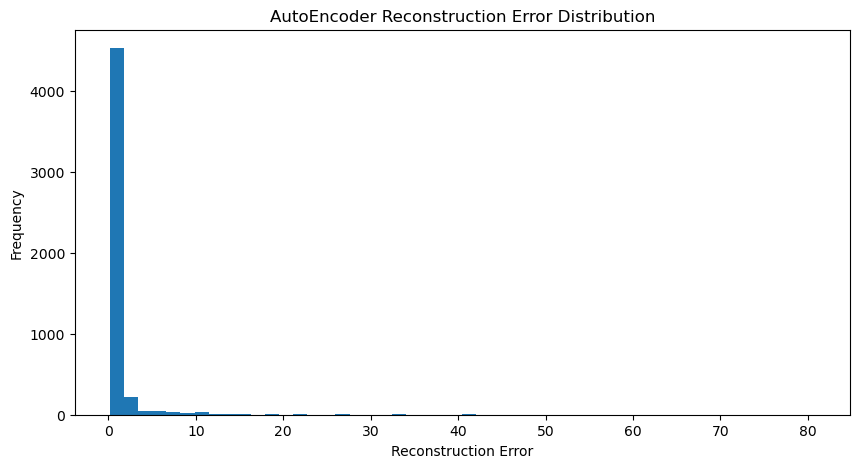

In [7]:
""" 
6. Reconstruction Error Analysis
"""
import numpy as np
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    reconstructed = model(X_tensor)
    reconstruction_errors = torch.mean((reconstructed - X_tensor) ** 2, dim=1).numpy()

print("Reconstruction error stats:")
print("Mean:", reconstruction_errors.mean())
print("Std:", reconstruction_errors.std())
print("Min:", reconstruction_errors.min())
print("Max:", reconstruction_errors.max())

plt.figure(figsize=(10, 5))
plt.hist(reconstruction_errors, bins=50)
plt.title("AutoEncoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

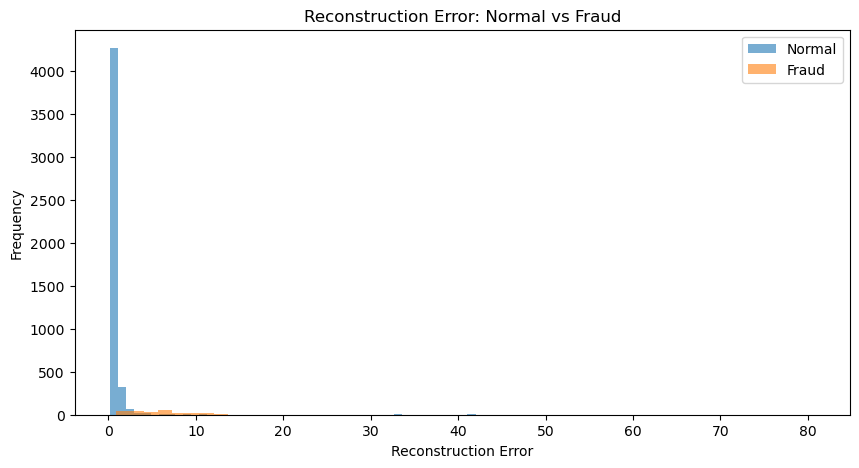

In [8]:
y = df["is_fraud"].astype(int).values

normal_errors = reconstruction_errors[y == 0]
fraud_errors = reconstruction_errors[y == 1]

plt.figure(figsize=(10, 5))
plt.hist(normal_errors, bins=50, alpha=0.6, label="Normal")
plt.hist(fraud_errors, bins=50, alpha=0.6, label="Fraud")
plt.title("Reconstruction Error: Normal vs Fraud")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [9]:
from sklearn.ensemble import IsolationForest

if_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
)

if_model.fit(X)

if_predictions = if_model.predict(X)

if_scores = if_model.decision_function(X)

print(if_scores[:10])

[-0.01632933 -0.05030841 -0.13580032 -0.03809611 -0.04523927 -0.03489762
 -0.03818361 -0.03265821 -0.10400472 -0.03325231]


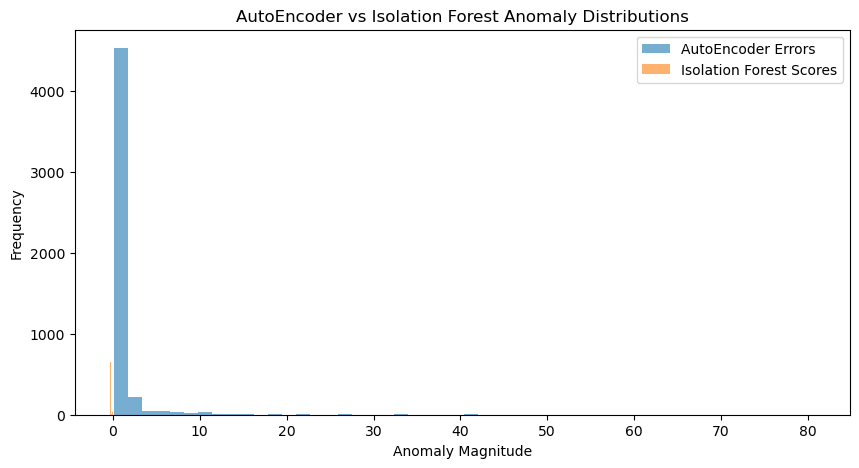

In [11]:
"""
7. Isolation Forest Comparison
"""
plt.figure(figsize=(10, 5))

plt.hist(
    reconstruction_errors,
    bins=50,
    alpha=0.6,
    label="AutoEncoder Errors"
)

plt.hist(
    -if_scores, bins=50, alpha=0.6, label="Isolation Forest Scores")

plt.title("AutoEncoder vs Isolation Forest Anomaly Distributions")

plt.xlabel("Anomaly Magnitude")
plt.ylabel("Frequency")
plt.legend()
plt.show()

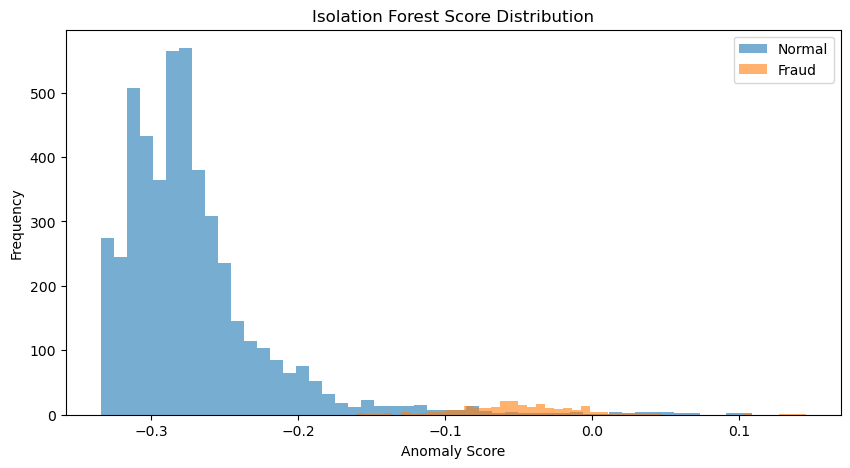

In [12]:
fraud_if_scores = -if_scores[y == 1]
normal_if_scores = -if_scores[y == 0]

plt.figure(figsize=(10, 5))
plt.hist(normal_if_scores, bins=50, alpha=0.6, label="Normal")
plt.hist(fraud_if_scores, bins=50, alpha=0.6, label="Fraud")

plt.title("Isolation Forest Score Distribution")

plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [13]:
"""
8. Latency Benchmarking
"""
import time
SAMPLE_SIZE = 1000

# -----------------------------
# Isolation Forest Benchmark
# -----------------------------

start_time = time.time()
for _ in range(SAMPLE_SIZE):

    if_model.predict(X.iloc[:1])

if_latency = (
    time.time() - start_time
) / SAMPLE_SIZE


# -----------------------------
# AutoEncoder Benchmark
# -----------------------------

sample_tensor = X_tensor[:1]

model.eval()

start_time = time.time()

with torch.no_grad():

    for _ in range(SAMPLE_SIZE):

        _ = model(sample_tensor)

ae_latency = (
    time.time() - start_time
) / SAMPLE_SIZE


print("\nLatency Benchmark:\n")

print(
    f"Isolation Forest Avg Latency: "
    f"{if_latency * 1000:.4f} ms"
)

print(
    f"AutoEncoder Avg Latency: "
    f"{ae_latency * 1000:.4f} ms"
)


Latency Benchmark:

Isolation Forest Avg Latency: 6.5892 ms
AutoEncoder Avg Latency: 0.1032 ms


In [15]:
!pip install mlflow

  Using cached mlflow-3.12.0-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.12.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached databricks_sdk-0.110.0-py3-none-any.whl.metadata (43 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached starlette-0.52.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)


In [16]:
"""
9. MLFlow Logging
"""
import mlflow

mlflow.set_experiment("AutoEncoder-vs-IsolationForest")

with mlflow.start_run():
    mlflow.log_param("autoencoder_epochs", EPOCHS)
    mlflow.log_metric("autoencoder_final_loss", loss.item())
    mlflow.log_metric("if_avg_latency_ms", if_latency * 1000)
    mlflow.log_metric("ae_avg_latency_ms", ae_latency * 1000)
    mlflow.log_metric("reconstruction_error_mean", reconstruction_errors.mean())

    print("MLflow comparison metrics logged.")

2026/05/25 11:51:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/25 11:51:28 INFO mlflow.store.db.utils: Updating database tables
2026/05/25 11:51:29 INFO mlflow.tracking.fluent: Experiment with name 'AutoEncoder-vs-IsolationForest' does not exist. Creating a new experiment.


MLflow comparison metrics logged.


Although the AutoEncoder achieved lower raw inference latency
in this controlled benchmark, Isolation Forest remained the
preferred production choice due to:

- lower operational complexity
- simpler deployment requirements
- no neural training dependency
- no feature normalization dependency
- easier retraining workflows
- lower infrastructure overhead
- simpler debugging and monitoring behavior

The AutoEncoder introduced additional engineering overhead
including neural network training, reconstruction threshold
calibration, scaling pipelines, and PyTorch runtime management.

For RealSignal's lightweight streaming fraud monitoring
architecture, Isolation Forest provided the most practical
balance between operational simplicity, maintainability,
and anomaly detection capability.